# Example of usage of open_save code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [14]:
R = 2.
r = 1.

NGSOLVE = True

lc = 0.3

if NGSOLVE:
    from cases.open_space.ngsolve_geometries import CleanCircle, AnularDomain, Regions
    mesh = AnularDomain(R=R, r=r, verbosity=0, lc=lc)
    mesh = CleanCircle(R=R, verbosity=0, lc=lc)
else:
    raise NotImplementedError
    from cases.open_space.gmsh_geometries import CleanWaveguide, WaveguideRegions
    mesh = CleanWaveguide(R=R, H=H, verbose=True, lc=lc)


In [15]:
list(Regions)

[<Regions.OMEGA: 'Omega'>,
 <Regions.SIGMA: 'Sigma'>,
 <Regions.d_Omega: 'd_Omega'>]

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [16]:
from trefftz.dg.boundary_conditions import DirichletBC, NtDBC

In [17]:
boundary_conditions = {Regions.d_Omega: DirichletBC,
                       Regions.SIGMA: NtDBC(truncating_radius=R, data=1.)}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [18]:
from trefftz.dg.serial_kernels import DirichletKernel, UltraWeakKernel


as well as specific ones (for a circular NtD map):

In [19]:
from cases.open_space.numerical_kernels import NtDNon_Local_circle, NtDLocal_circle

Now the numerics (the configuration of kernels) is almost a dictionary:

In [ ]:
from trefftz.dg.assemblers import SerialNumerics
n = 0
numerics = SerialNumerics(interior_kernel=UltraWeakKernel(a=0.5, b=0.5),
                          local_boundary_kernels={DirichletBC: DirichletKernel(d_1=0.5),
                                                  NtDBC: NtDLocal_circle(R=R, d_2=0.5, n=1)},
                          nonlocal_boundary_kernels={NtDBC: NtD_nonlocal(R=R, d_2=0.5, M=10, H=H)})

NameError: name 'H' is not defined

We should also choose a local basis

In [8]:
from trefftz.dg.basis import LinearlySpacedBasis
k = 8.0
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, k=k, N_theta=15)

and an assembler:

In [9]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

so we can set the problem:

In [10]:
from trefftz.problem import Problem  # (I don't think "problem" uses "numerics" any more.)
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler)  #, numerics=numerics)

In [11]:
A = P.assemble_LHS()

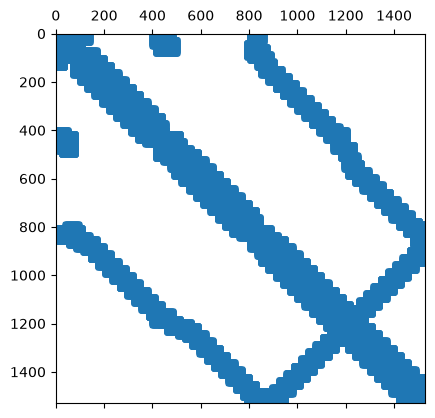

In [12]:
import matplotlib.pyplot as plt 
plt.spy(A)

In [13]:
b = P.assemble_RHS()

In [14]:
P.solve()

In [15]:
P.u_h.coefficients.reshape((-1,3))

array([[ 1.12532781e+01 -18.75488515j,  1.95708776e+01 -11.41216057j,
        -1.37829714e+01 -23.15414765j],
       [ 8.76694300e+00 +29.92939145j, -9.15207430e+00 -25.29797956j,
        -4.60264296e+00 +13.03917566j],
       [ 8.92934205e-02  +4.70803284j, -6.39367798e-01  -0.73578054j,
        -7.63130325e-01  -1.32443831j],
       ...,
       [-4.40665927e+02 -93.11399426j,  4.11621092e+02  -2.27480679j,
         1.64134277e+02-315.84055327j],
       [ 2.81143258e+02 -74.32332648j, -5.39870855e+01+209.94182298j,
        -5.52660267e+01-123.70234509j],
       [ 4.96498207e+01  +9.68396464j, -5.39936358e+01 +38.75783584j,
         8.39076042e+01+141.63354029j]], shape=(510, 3))

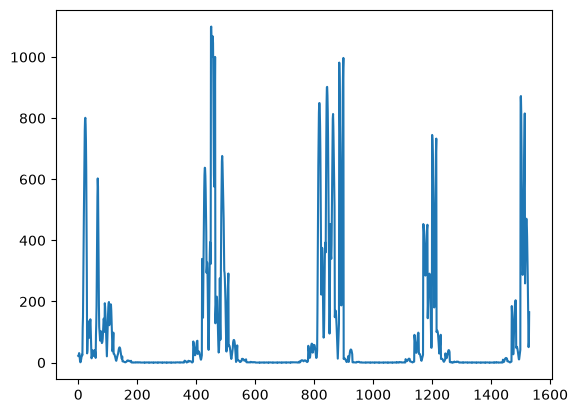

In [16]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [17]:
import numpy as np
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(0., H, int(N*H/R))
X, Y = np.meshgrid(x, y)
Z = P.u_h(X.ravel(), Y.ravel()).reshape(X.shape)

(0.0, 1.0)

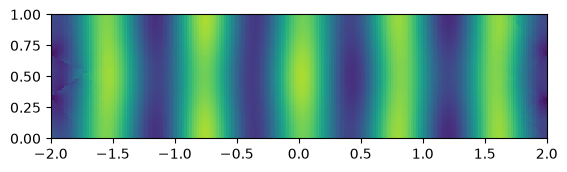

In [18]:
import matplotlib.pyplot as plt 
plt.pcolormesh(X, Y, Z.real, vmin=-3, vmax=3)
plt.axis('square')
plt.xlim([-R, R])
plt.ylim([0., H])